# Model Improvement and Comparison

In this section, we aim to improve model performance by testing multiple machine learning models and comparing their results.

We evaluate:
- Logistic Regression
- SVM
- Random Forest
- Tuned Random Forest

Focus metric: Death Recall

In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [37]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(class_weight="balanced", probability=True))
    ]),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    )
}

In [39]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    death_recall = report["1"]["recall"]
    death_f1 = report["1"]["f1-score"]

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = None

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Death Recall": death_recall,
        "Death F1": death_f1,
        "ROC-AUC": auc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Death Recall,Death F1,ROC-AUC
0,Logistic Regression,0.800000,0.578947,0.647059,0.854942
1,SVM,0.716667,0.526316,0.540541,0.856226
2,Random Forest,0.850000,0.631579,0.727273,0.910141


In [40]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best CV recall:", grid_rf.best_score_)

Best parameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV recall: 0.8041666666666666


In [41]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Tuned Random Forest Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        41
           1       0.76      0.68      0.72        19

    accuracy                           0.83        60
   macro avg       0.81      0.79      0.80        60
weighted avg       0.83      0.83      0.83        60



In [42]:
tuned_report = classification_report(y_test, y_pred_rf, output_dict=True)

results_df = pd.DataFrame(results)

tuned_row = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Death Recall": tuned_report["1"]["recall"],
    "Death F1": tuned_report["1"]["f1-score"],
    "ROC-AUC": roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
}])

results_df = pd.concat([results_df, tuned_row], ignore_index=True)

results_df

,Model,Accuracy,Death Recall,Death F1,ROC-AUC
0,Logistic Regression,0.800000,0.578947,0.647059,0.854942
1,SVM,0.716667,0.526316,0.540541,0.856226
2,Random Forest,0.850000,0.631579,0.727273,0.910141
3,Tuned Random Forest,0.833333,0.684211,0.722222,0.898588


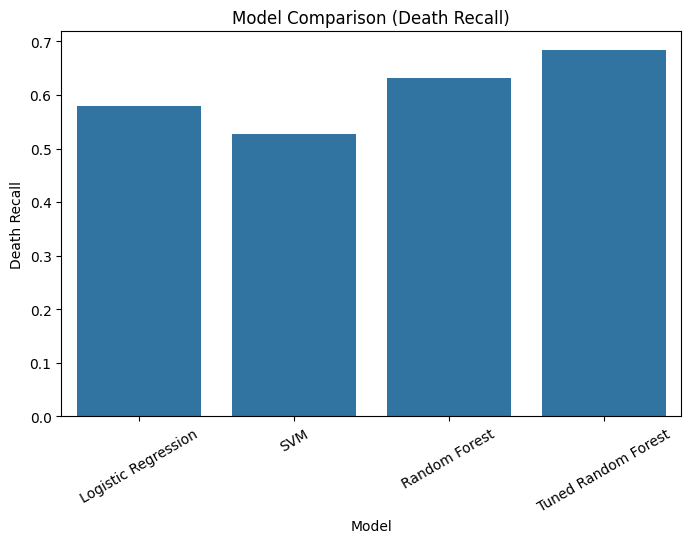

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="Death Recall")
plt.title("Model Comparison (Death Recall)")
plt.xticks(rotation=30)
plt.show()

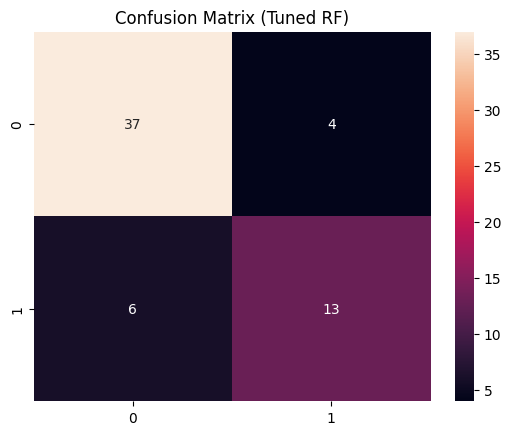

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Tuned RF)")
plt.show()

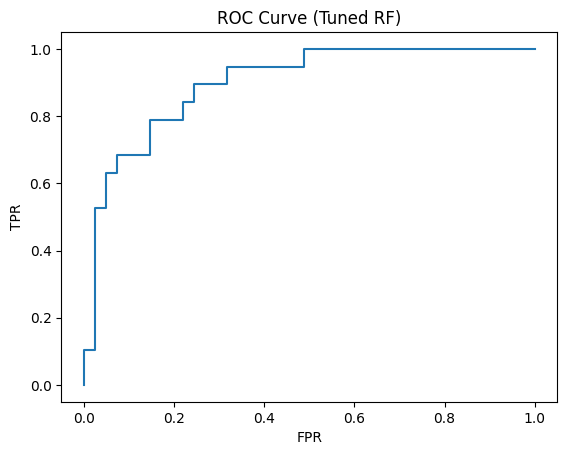

In [45]:
from sklearn.metrics import roc_curve

y_prob = best_rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve (Tuned RF)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()